#8. Семантический поиск и RAG


---

## Содержание

1. Введение в семантический поиск
2. Разбиение текста на фрагменты (Chunking)
3. Лексический поиск: BM25
4. Плотные векторные представления (Dense Embeddings)
5. Визуализация эмбеддингов
6. Векторный поиск с FAISS
7. Кросс-энкодер для переранжирования
8. RAG: поиск + генерация
9. Полноценный RAG-конвейер
10. Самостоятельные задания

## 1. Введение в семантический поиск

Классический (лексический) поиск ищет совпадения ключевых слов.
Семантический поиск находит документы, близкие по смыслу, даже если
они используют другие слова.

Два подхода к поиску:

- **Лексический (BM25, TF-IDF)**: основан на частоте слов, быстрый,
  но не учитывает синонимы и перефразирования.
- **Семантический (Dense Retrieval)**: основан на векторных представлениях
  (эмбеддингах), учитывает смысл, но требует модель эмбеддингов.

**RAG (Retrieval-Augmented Generation)** -- техника, сочетающая поиск
релевантных фрагментов из базы знаний с генерацией текста языковой моделью.
Это позволяет модели отвечать на вопросы, основываясь на конкретных документах.

## 2. Разбиение текста на фрагменты (Chunking)

Перед индексацией документы разбивают на фрагменты (chunks).
Это необходимо, потому что:
- Модели эмбеддингов имеют ограничение на длину входа.
- Поиск работает точнее на коротких фрагментах.
- Контекстное окно генеративной модели ограничено.

Стратегии разбиения:
- По фиксированному числу символов/слов.
- По предложениям.
- По абзацам.
- С перекрытием (overlap) для сохранения контекста.

In [ ]:
# Установка зависимостей (раскомментируйте при необходимости)
# !pip install sentence-transformers faiss-cpu rank-bm25 transformers torch matplotlib numpy -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Фиксируем случайное зерно
SEED = 42
np.random.seed(SEED)

# Подготовка корпуса документов
documents = [
    "Machine learning is a subset of artificial intelligence that enables "
    "systems to learn and improve from experience without being explicitly programmed. "
    "It focuses on developing algorithms that can access data and use it to learn for themselves.",

    "Deep learning is a branch of machine learning based on artificial neural networks. "
    "It uses multiple layers of processing to progressively extract higher-level features "
    "from raw input data. Deep learning has achieved remarkable results in image recognition.",

    "Natural language processing (NLP) is a field of computer science and linguistics "
    "concerned with the interactions between computers and human language. "
    "NLP combines computational linguistics with statistical and machine learning methods.",

    "Computer vision is a field of artificial intelligence that trains computers "
    "to interpret and understand the visual world. Using digital images and deep learning "
    "models, machines can accurately identify and classify objects.",

    "Reinforcement learning is a type of machine learning where an agent learns "
    "to make decisions by performing actions in an environment to maximize cumulative reward. "
    "It is inspired by behavioral psychology and has been used in game playing and robotics.",

    "Transfer learning is a technique where a model trained on one task is reused "
    "as the starting point for a model on a second task. This approach is especially "
    "useful when the second task has limited training data available.",

    "Generative adversarial networks (GANs) consist of two neural networks that "
    "compete against each other. The generator creates new data instances, while the "
    "discriminator evaluates them. GANs are used for image generation and data augmentation.",

    "Transformer architecture has revolutionized natural language processing. "
    "It uses self-attention mechanisms to process input data in parallel, "
    "enabling much faster training than previous recurrent neural network approaches.",

    "Embeddings are dense vector representations of data such as words, sentences, "
    "or documents. They capture semantic relationships, allowing similar items to have "
    "similar vector representations in a continuous vector space.",

    "Vector databases store and index high-dimensional vectors for efficient similarity "
    "search. They are essential for semantic search, recommendation systems, and "
    "retrieval-augmented generation (RAG) pipelines.",
]

print(f"Корпус: {len(documents)} документов")
for i, doc in enumerate(documents):
    print(f"  [{i}] {doc[:70]}...")

Корпус: 10 документов
  [0] Machine learning is a subset of artificial intelligence that enables s...
  [1] Deep learning is a branch of machine learning based on artificial neur...
  [2] Natural language processing (NLP) is a field of computer science and l...
  [3] Computer vision is a field of artificial intelligence that trains comp...
  [4] Reinforcement learning is a type of machine learning where an agent le...
  [5] Transfer learning is a technique where a model trained on one task is ...
  [6] Generative adversarial networks (GANs) consist of two neural networks ...
  [7] Transformer architecture has revolutionized natural language processin...
  [8] Embeddings are dense vector representations of data such as words, sen...
  [9] Vector databases store and index high-dimensional vectors for efficien...


In [ ]:
def chunk_by_words(text, chunk_size=20, overlap=5):
    """Разбить текст на фрагменты по словам с перекрытием."""
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap
    return chunks


def chunk_by_sentences(text):
    """Разбить текст на предложения."""
    # Простая разбивка по точкам
    sentences = [s.strip() for s in text.split(".") if s.strip()]
    return [s + "." for s in sentences]


# Демонстрация
sample_text = documents[0]
print("Исходный текст:")
print(sample_text)
print()

print("Разбиение по словам (размер=15, перекрытие=5):")
word_chunks = chunk_by_words(sample_text, chunk_size=15, overlap=5)
for i, chunk in enumerate(word_chunks):
    print(f"  Фрагмент {i}: {chunk}")
print()

print("Разбиение по предложениям:")
sent_chunks = chunk_by_sentences(sample_text)
for i, chunk in enumerate(sent_chunks):
    print(f"  Фрагмент {i}: {chunk}")

Исходный текст:
Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed. It focuses on developing algorithms that can access data and use it to learn for themselves.

Разбиение по словам (размер=15, перекрытие=5):
  Фрагмент 0: Machine learning is a subset of artificial intelligence that enables systems to learn and improve
  Фрагмент 1: systems to learn and improve from experience without being explicitly programmed. It focuses on developing
  Фрагмент 2: programmed. It focuses on developing algorithms that can access data and use it to learn
  Фрагмент 3: and use it to learn for themselves.

Разбиение по предложениям:
  Фрагмент 0: Machine learning is a subset of artificial intelligence that enables systems to learn and improve from experience without being explicitly programmed.
  Фрагмент 1: It focuses on developing algorithms that can access data and use it to learn for themselves.


## 3. Лексический поиск: BM25

BM25 (Best Matching 25) -- алгоритм ранжирования, основанный на
частоте терминов (TF) и обратной частоте документов (IDF).

Формула BM25 для документа D и запроса Q:
```
score(D, Q) = SUM[ IDF(qi) * (f(qi, D) * (k1 + 1)) / (f(qi, D) + k1 * (1 - b + b * |D| / avgdl)) ]
```

где:
- f(qi, D) -- частота термина qi в документе D
- |D| -- длина документа D
- avgdl -- средняя длина документа в коллекции
- k1 и b -- параметры настройки (обычно k1=1.5, b=0.75)

In [ ]:
# !pip install rank_bm25

In [ ]:
from rank_bm25 import BM25Okapi

# Токенизация документов (простая -- по словам в нижнем регистре)
tokenized_docs = [doc.lower().split() for doc in documents]

# Создание индекса BM25
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=3):
    """Поиск документов с помощью BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(scores[idx]),
            "text": documents[idx]
        })
    return results, scores

# Пример поиска
query = "how do neural networks learn from images"
results, all_scores = bm25_search(query, top_k=3)

print(f"Запрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Скор: {r['score']:.2f}")
    print(f"      {r['text'][:80]}...")
    print()

Запрос: 'how do neural networks learn from images'

  [0] Скор: 3.70
      Machine learning is a subset of artificial intelligence that enables systems to ...

  [6] Скор: 3.37
      Generative adversarial networks (GANs) consist of two neural networks that compe...

  [1] Скор: 1.89
      Deep learning is a branch of machine learning based on artificial neural network...



In [ ]:
from rank_bm25 import BM25Okapi

# Токенизация документов (простая -- по словам в нижнем регистре)
tokenized_docs = [doc.lower().split() for doc in documents]

# Создание индекса BM25
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=3):
    """Поиск документов с помощью BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(scores[idx]),
            "text": documents[idx]
        })
    return results, scores

# Пример поиска
query = "how do neural networks learn from images"
results, all_scores = bm25_search(query, top_k=3)

print(f"Запрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Скор: {r['score']:.2f}")
    print(f"      {r['text'][:80]}...")
    print()

Запрос: 'how do neural networks learn from images'

  [0] Скор: 3.70
      Machine learning is a subset of artificial intelligence that enables systems to ...

  [6] Скор: 3.37
      Generative adversarial networks (GANs) consist of two neural networks that compe...

  [1] Скор: 1.89
      Deep learning is a branch of machine learning based on artificial neural network...



In [ ]:
from rank_bm25 import BM25Okapi

# Токенизация документов (простая -- по словам в нижнем регистре)
tokenized_docs = [doc.lower().split() for doc in documents]

# Создание индекса BM25
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=3):
    """Поиск документов с помощью BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(scores[idx]),
            "text": documents[idx]
        })
    return results, scores

# Пример поиска
query = "how do neural networks learn from images"
results, all_scores = bm25_search(query, top_k=3)

print(f"Запрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Скор: {r['score']:.2f}")
    print(f"      {r['text'][:80]}...")
    print()

Запрос: 'how do neural networks learn from images'

  [0] Скор: 3.70
      Machine learning is a subset of artificial intelligence that enables systems to ...

  [6] Скор: 3.37
      Generative adversarial networks (GANs) consist of two neural networks that compe...

  [1] Скор: 1.89
      Deep learning is a branch of machine learning based on artificial neural network...



In [ ]:
from rank_bm25 import BM25Okapi

# Токенизация документов (простая -- по словам в нижнем регистре)
tokenized_docs = [doc.lower().split() for doc in documents]

# Создание индекса BM25
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query, top_k=3):
    """Поиск документов с помощью BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            "index": int(idx),
            "score": float(scores[idx]),
            "text": documents[idx]
        })
    return results, scores

# Пример поиска
query = "how do neural networks learn from images"
results, all_scores = bm25_search(query, top_k=3)

print(f"Запрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Скор: {r['score']:.2f}")
    print(f"      {r['text'][:80]}...")
    print()

Запрос: 'how do neural networks learn from images'

  [0] Скор: 3.70
      Machine learning is a subset of artificial intelligence that enables systems to ...

  [6] Скор: 3.37
      Generative adversarial networks (GANs) consist of two neural networks that compe...

  [1] Скор: 1.89
      Deep learning is a branch of machine learning based on artificial neural network...



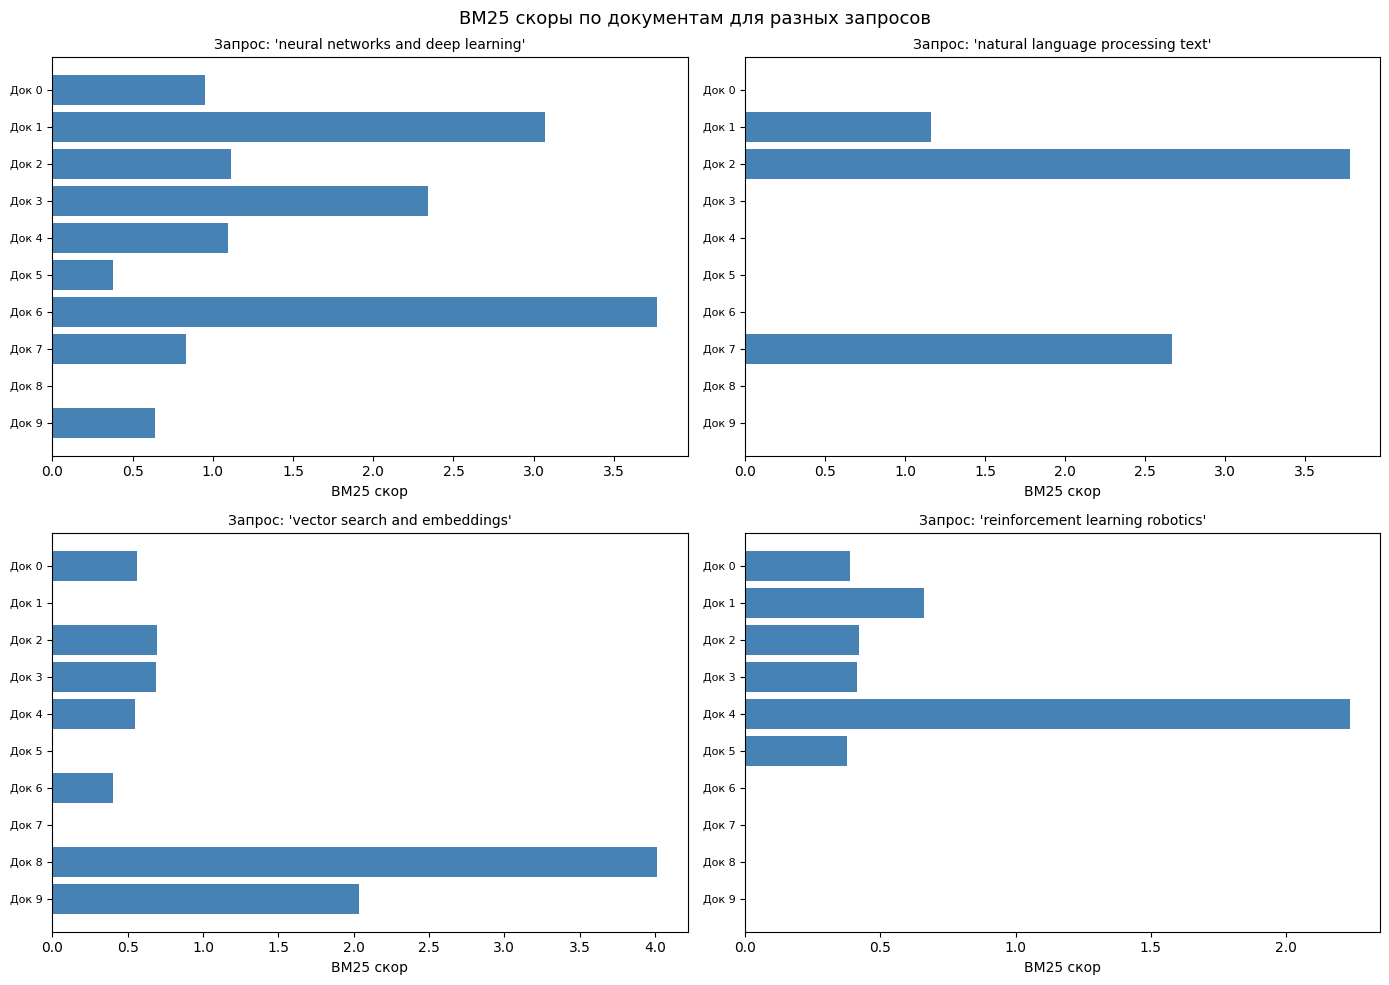

In [ ]:
# Визуализация BM25 скоров для разных запросов
queries = [
    "neural networks and deep learning",
    "natural language processing text",
    "vector search and embeddings",
    "reinforcement learning robotics",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, query in zip(axes, queries):
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)

    colors = ["steelblue" if s > 0 else "lightgray" for s in scores]
    ax.barh(range(len(scores)), scores, color=colors)
    ax.set_yticks(range(len(scores)))
    ax.set_yticklabels([f"Док {i}" for i in range(len(scores))], fontsize=8)
    ax.set_xlabel("BM25 скор")
    ax.set_title(f"Запрос: '{query}'", fontsize=10)
    ax.invert_yaxis()

plt.suptitle("BM25 скоры по документам для разных запросов", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Плотные векторные представления (Dense Embeddings)

Модели эмбеддингов (например, sentence-transformers) преобразуют тексты
в плотные числовые векторы фиксированной размерности. Тексты с близким
смыслом получают близкие векторы.

Мы используем модель all-MiniLM-L6-v2:
- Размерность: 384
- Быстрая, работает на CPU
- Хорошее качество для английского языка

In [ ]:
from sentence_transformers import SentenceTransformer

# Загрузка модели эмбеддингов
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

# Кодирование документов
doc_embeddings = embed_model.encode(documents, show_progress_bar=True)
print(f"Форма матрицы эмбеддингов: {doc_embeddings.shape}")
print(f"Размерность одного эмбеддинга: {doc_embeddings.shape[1]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Форма матрицы эмбеддингов: (10, 384)
Размерность одного эмбеддинга: 384


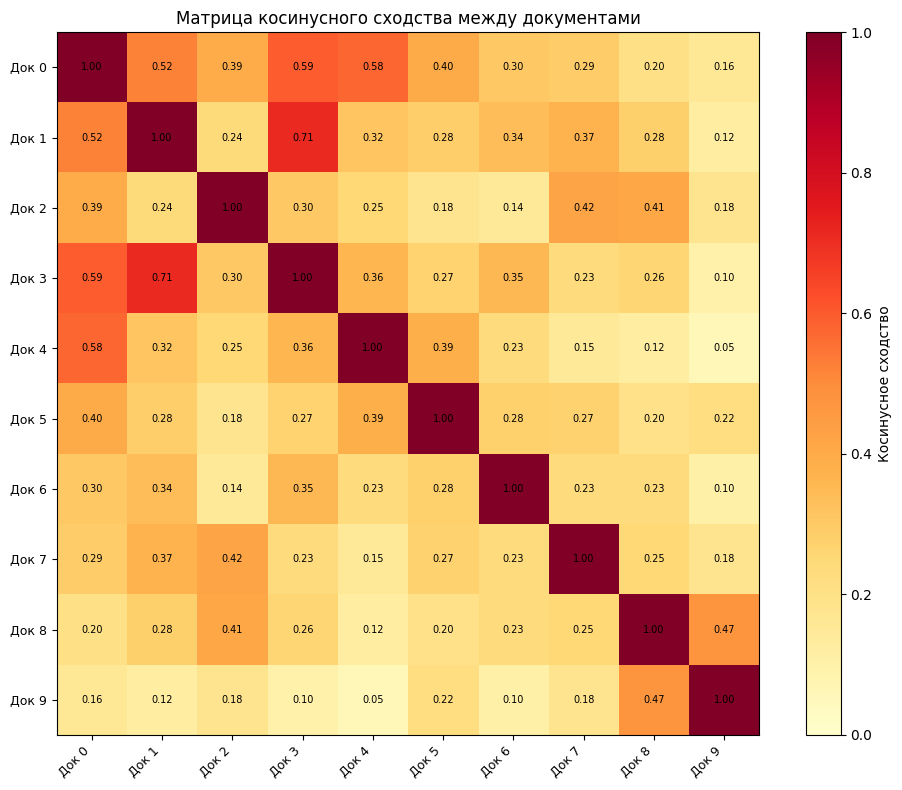

In [ ]:
# Косинусное сходство между документами
from numpy.linalg import norm

def cosine_similarity(a, b):
    """Вычислить косинусное сходство между двумя векторами."""
    return np.dot(a, b) / (norm(a) * norm(b))


# Матрица сходства
n = len(documents)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = cosine_similarity(doc_embeddings[i], doc_embeddings[j])

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
short_labels = [f"Док {i}" for i in range(n)]
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)
ax.set_title("Матрица косинусного сходства между документами")

# Добавляем значения в ячейки
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, label="Косинусное сходство")
plt.tight_layout()
plt.show()

## 5. Визуализация эмбеддингов

Визуализируем 384-мерные эмбеддинги в 2D с помощью PCA
(метод главных компонент).

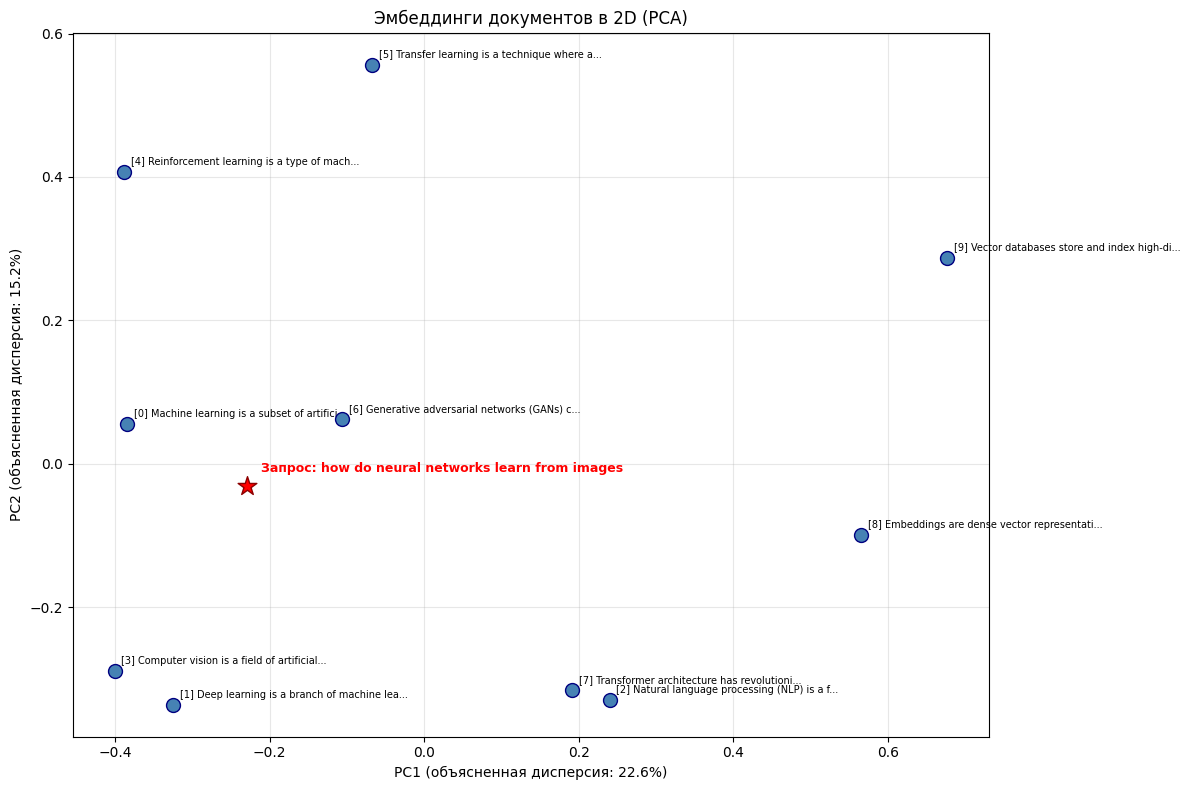

In [ ]:
from sklearn.decomposition import PCA

# Уменьшение размерности до 2D
pca = PCA(n_components=2, random_state=SEED)
embeddings_2d = pca.fit_transform(doc_embeddings)

# Также кодируем запрос
query = "how do neural networks learn from images"
query_emb = embed_model.encode([query])
query_2d = pca.transform(query_emb)

fig, ax = plt.subplots(figsize=(12, 8))

# Документы
scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                     s=100, c="steelblue", edgecolors="navy", zorder=5)

# Подписи документов
for i in range(len(documents)):
    short = documents[i][:40] + "..."
    ax.annotate(f"[{i}] {short}", (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                fontsize=7, xytext=(5, 5), textcoords="offset points")

# Запрос
ax.scatter(query_2d[:, 0], query_2d[:, 1],
           s=200, c="red", marker="*", edgecolors="darkred", zorder=10)
ax.annotate(f"Запрос: {query}", (query_2d[0, 0], query_2d[0, 1]),
            fontsize=9, color="red", xytext=(10, 10), textcoords="offset points",
            fontweight="bold")

ax.set_xlabel(f"PC1 (объясненная дисперсия: {pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 (объясненная дисперсия: {pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Эмбеддинги документов в 2D (PCA)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Векторный поиск с FAISS

FAISS (Facebook AI Similarity Search) -- библиотека для эффективного
поиска ближайших соседей в пространстве векторов.

Поддерживает различные типы индексов:
- **Flat**: точный поиск (перебор всех векторов).
- **IVF**: приближенный поиск с кластеризацией.
- **HNSW**: граф ближайших соседей.

Для небольших коллекций используем точный индекс (Flat).

In [ ]:
# !pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 53.5 MB/s eta 0:00:00


In [ ]:
import faiss

# Создание индекса FAISS
dimension = doc_embeddings.shape[1]  # 384
index = faiss.IndexFlatIP(dimension)  # Inner Product (для нормализованных = cosine)

# Нормализация векторов для косинусного сходства
doc_emb_normalized = doc_embeddings / np.linalg.norm(doc_embeddings, axis=1, keepdims=True)
index.add(doc_emb_normalized.astype(np.float32))

print(f"Индекс FAISS создан. Количество векторов: {index.ntotal}")
print(f"Размерность: {dimension}")


def semantic_search(query, top_k=3):
    """Семантический поиск через FAISS."""
    query_emb = embed_model.encode([query])
    query_emb_norm = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)

    scores, indices = index.search(query_emb_norm.astype(np.float32), top_k)

    results = []
    for i in range(top_k):
        idx = int(indices[0][i])
        results.append({
            "index": idx,
            "score": float(scores[0][i]),
            "text": documents[idx]
        })
    return results


# Тестирование
query = "how do neural networks learn from images"
results = semantic_search(query, top_k=3)

print(f"\nЗапрос: '{query}'")
print()
for r in results:
    print(f"  [{r['index']}] Сходство: {r['score']:.4f}")
    print(f"      {r['text'][:80]}...")
    print()

Индекс FAISS создан. Количество векторов: 10
Размерность: 384

Запрос: 'how do neural networks learn from images'

  [1] Сходство: 0.5977
      Deep learning is a branch of machine learning based on artificial neural network...

  [3] Сходство: 0.5760
      Computer vision is a field of artificial intelligence that trains computers to i...

  [6] Сходство: 0.4351
      Generative adversarial networks (GANs) consist of two neural networks that compe...



In [ ]:
# Сравнение BM25 и семантического поиска
comparison_queries = [
    "systems that learn without explicit programming",  # перефразирование
    "generating realistic images with AI",              # семантическая близость
    "attention mechanism in transformers",              # терминология
]

print("=== Сравнение BM25 vs Семантический поиск ===")
print()

for query in comparison_queries:
    bm25_results, _ = bm25_search(query, top_k=3)
    sem_results = semantic_search(query, top_k=3)

    print(f"Запрос: '{query}'")
    print(f"  BM25 top-3: документы {[r['index'] for r in bm25_results]}")
    print(f"  Семантический top-3: документы {[r['index'] for r in sem_results]}")
    print()

=== Сравнение BM25 vs Семантический поиск ===

Запрос: 'systems that learn without explicit programming'
  BM25 top-3: документы [0, 3, 6]
  Семантический top-3: документы [0, 4, 5]

Запрос: 'generating realistic images with AI'
  BM25 top-3: документы [2, 3, 8]
  Семантический top-3: документы [3, 6, 1]

Запрос: 'attention mechanism in transformers'
  BM25 top-3: документы [4, 7, 8]
  Семантический top-3: документы [7, 5, 6]



## 7. Кросс-энкодер для переранжирования

Двухэтапная схема поиска:
1. **Bi-encoder** (быстрый): кодирует запрос и документы отдельно,
   находит кандидатов через FAISS.
2. **Cross-encoder** (точный): обрабатывает пару (запрос, документ)
   совместно, дает более точную оценку релевантности.

Кросс-энкодер медленнее, поэтому применяется только к небольшому
набору кандидатов (top-k из первого этапа).

In [ ]:
from sentence_transformers import CrossEncoder

# Загрузка кросс-энкодера
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(query, candidate_docs, top_k=3):
    """Переранжирование документов кросс-энкодером."""
    pairs = [(query, doc) for doc in candidate_docs]
    scores = cross_encoder.predict(pairs)

    ranked_indices = np.argsort(scores)[::-1][:top_k]
    results = []
    for idx in ranked_indices:
        results.append({
            "original_index": idx,
            "score": float(scores[idx]),
            "text": candidate_docs[idx]
        })
    return results, scores


# Двухэтапный поиск
query = "how do machines understand human language"

# Этап 1: быстрый поиск (top-5 кандидатов)
stage1_results = semantic_search(query, top_k=5)
candidate_texts = [r["text"] for r in stage1_results]
candidate_indices = [r["index"] for r in stage1_results]

print(f"Запрос: '{query}'")
print()
print("Этап 1 -- Bi-encoder (FAISS):")
for r in stage1_results:
    print(f"  [{r['index']}] Сходство: {r['score']:.4f} -- {r['text'][:60]}...")
print()

# Этап 2: переранжирование (top-3)
stage2_results, ce_scores = rerank(query, candidate_texts, top_k=3)

print("Этап 2 -- Cross-encoder (переранжирование):")
for r in stage2_results:
    orig_doc_idx = candidate_indices[r["original_index"]]
    print(f"  [{orig_doc_idx}] Скор: {r['score']:.4f} -- {r['text'][:60]}...")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Запрос: 'how do machines understand human language'

Этап 1 -- Bi-encoder (FAISS):
  [0] Сходство: 0.4363 -- Machine learning is a subset of artificial intelligence that...
  [2] Сходство: 0.4356 -- Natural language processing (NLP) is a field of computer sci...
  [3] Сходство: 0.4241 -- Computer vision is a field of artificial intelligence that t...
  [7] Сходство: 0.4023 -- Transformer architecture has revolutionized natural language...
  [1] Сходство: 0.3365 -- Deep learning is a branch of machine learning based on artif...

Этап 2 -- Cross-encoder (переранжирование):
  [2] Скор: 0.0316 -- Natural language processing (NLP) is a field of computer sci...
  [0] Скор: -2.2804 -- Machine learning is a subset of artificial intelligence that...
  [3] Скор: -4.1244 -- Computer vision is a field of artificial intelligence that t...


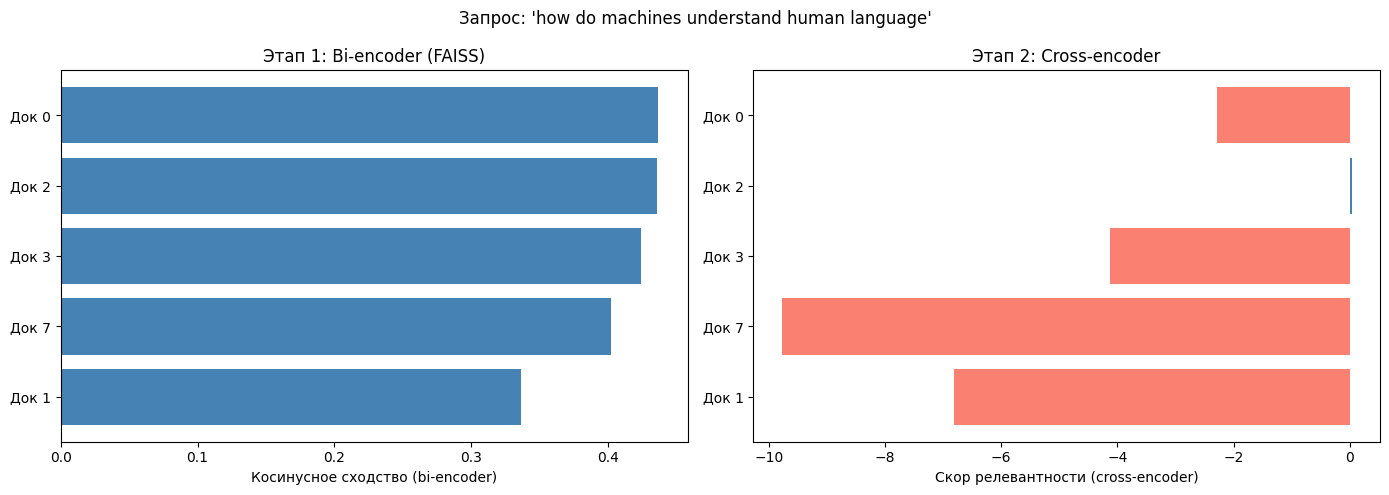

In [ ]:
# Визуализация: сравнение скоров bi-encoder и cross-encoder
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bi-encoder скоры
bi_scores = [r["score"] for r in stage1_results]
bi_labels = [f"Док {r['index']}" for r in stage1_results]
axes[0].barh(bi_labels, bi_scores, color="steelblue")
axes[0].set_xlabel("Косинусное сходство (bi-encoder)")
axes[0].set_title("Этап 1: Bi-encoder (FAISS)")
axes[0].invert_yaxis()

# Cross-encoder скоры
ce_labels = [f"Док {candidate_indices[i]}" for i in range(len(ce_scores))]
ce_colors = ["steelblue" if s > 0 else "salmon" for s in ce_scores]
axes[1].barh(ce_labels, ce_scores, color=ce_colors)
axes[1].set_xlabel("Скор релевантности (cross-encoder)")
axes[1].set_title("Этап 2: Cross-encoder")
axes[1].invert_yaxis()

plt.suptitle(f"Запрос: '{query}'", fontsize=12)
plt.tight_layout()
plt.show()

## 8. RAG: поиск + генерация

RAG (Retrieval-Augmented Generation) объединяет:
1. **Retrieval**: поиск релевантных фрагментов из базы знаний.
2. **Augmented**: добавление найденных фрагментов в контекст промпта.
3. **Generation**: генерация ответа языковой моделью на основе контекста.

Преимущества RAG:
- Модель отвечает на основе актуальных данных, а не только обучающей выборки.
- Снижение галлюцинаций за счет привязки к источникам.
- Легко обновлять базу знаний без переобучения модели.

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

# Загрузка генеративной модели
gen_tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
gen_model = GPT2LMHeadModel.from_pretrained("gpt2")
gen_model.eval()

def generate_answer(prompt, max_new_tokens=80):
    """Генерация ответа с помощью GPT-2."""
    torch.manual_seed(SEED)
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = gen_model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=0.5,
            do_sample=True,
            pad_token_id=gen_tokenizer.eos_token_id,
            no_repeat_ngram_size=3
        )
    full_text = gen_tokenizer.decode(outputs[0], skip_special_tokens=True)
    return full_text[len(prompt):].strip()


def simple_rag(query, top_k=3):
    """Простой RAG: поиск + генерация."""
    # Шаг 1: Поиск релевантных документов
    results = semantic_search(query, top_k=top_k)

    # Шаг 2: Формирование контекста
    context_parts = []
    for i, r in enumerate(results):
        context_parts.append(f"Source {i+1}: {r['text']}")
    context = "\n".join(context_parts)

    # Шаг 3: Формирование промпта для генерации
    rag_prompt = (
        f"Based on the following sources, answer the question.\n\n"
        f"{context}\n\n"
        f"Question: {query}\n"
        f"Answer:"
    )

    # Шаг 4: Генерация ответа
    answer = generate_answer(rag_prompt, max_new_tokens=60)

    return {
        "query": query,
        "sources": results,
        "answer": answer,
        "prompt": rag_prompt
    }


# Тестирование RAG
rag_result = simple_rag("What is transfer learning and why is it useful?")

print("=== RAG результат ===")
print(f"Запрос: {rag_result['query']}")
print()
print("Найденные источники:")
for src in rag_result["sources"]:
    print(f"  [{src['index']}] {src['text'][:80]}...")
print()
print(f"Ответ: {rag_result['answer']}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


=== RAG результат ===
Запрос: What is transfer learning and why is it useful?

Найденные источники:
  [5] Transfer learning is a technique where a model trained on one task is reused as ...
  [0] Machine learning is a subset of artificial intelligence that enables systems to ...
  [4] Reinforcement learning is a type of machine learning where an agent learns to ma...

Ответ: Transfer Learning is a tool that allows systems to train on a set of tasks and then learn to perform those tasks for themselves without the need for any other training data.
.
The goal of transfer learning is to train a system on a task and then apply this knowledge to learn new tasks.


## 9. Полноценный RAG-конвейер

Объединим все компоненты в один класс: разбиение на фрагменты,
индексация, поиск (гибридный: BM25 + FAISS), переранжирование
и генерация ответа.

In [ ]:
class RAGPipeline:
    """Полноценный RAG-конвейер."""

    def __init__(self, embed_model_name="all-MiniLM-L6-v2"):
        self.embed_model = SentenceTransformer(embed_model_name)
        self.gen_tokenizer = gen_tokenizer
        self.gen_model = gen_model
        self.cross_encoder = cross_encoder
        self.documents = []
        self.chunks = []
        self.chunk_to_doc = []  # маппинг: индекс фрагмента -> индекс документа
        self.bm25 = None
        self.faiss_index = None
        self.chunk_embeddings = None

    def add_documents(self, docs, chunk_size=30, overlap=10):
        """Добавить документы в базу знаний."""
        self.documents = docs
        self.chunks = []
        self.chunk_to_doc = []

        for doc_idx, doc in enumerate(docs):
            doc_chunks = chunk_by_words(doc, chunk_size=chunk_size, overlap=overlap)
            for chunk in doc_chunks:
                self.chunks.append(chunk)
                self.chunk_to_doc.append(doc_idx)

        print(f"Документов: {len(docs)}")
        print(f"Фрагментов: {len(self.chunks)}")

        # Индексация BM25
        tokenized_chunks = [c.lower().split() for c in self.chunks]
        self.bm25 = BM25Okapi(tokenized_chunks)

        # Индексация FAISS
        self.chunk_embeddings = self.embed_model.encode(self.chunks)
        emb_norm = self.chunk_embeddings / np.linalg.norm(
            self.chunk_embeddings, axis=1, keepdims=True
        )
        self.faiss_index = faiss.IndexFlatIP(emb_norm.shape[1])
        self.faiss_index.add(emb_norm.astype(np.float32))

        print("Индексы BM25 и FAISS построены.")

    def hybrid_search(self, query, top_k=5, bm25_weight=0.3):
        """Гибридный поиск: BM25 + семантический."""
        # BM25 скоры
        bm25_scores = self.bm25.get_scores(query.lower().split())
        if bm25_scores.max() > 0:
            bm25_scores = bm25_scores / bm25_scores.max()

        # Семантические скоры
        query_emb = self.embed_model.encode([query])
        query_emb_norm = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)
        sem_scores, _ = self.faiss_index.search(
            query_emb_norm.astype(np.float32), len(self.chunks)
        )
        sem_scores_all = np.zeros(len(self.chunks))
        for i in range(len(self.chunks)):
            sim = cosine_similarity(query_emb_norm[0], self.chunk_embeddings[i] /
                                    np.linalg.norm(self.chunk_embeddings[i]))
            sem_scores_all[i] = sim

        # Комбинированный скор
        combined = bm25_weight * bm25_scores + (1 - bm25_weight) * sem_scores_all
        top_indices = np.argsort(combined)[::-1][:top_k]

        results = []
        for idx in top_indices:
            results.append({
                "chunk_index": int(idx),
                "doc_index": self.chunk_to_doc[idx],
                "score": float(combined[idx]),
                "text": self.chunks[idx]
            })
        return results

    def rerank(self, query, candidates, top_k=3):
        """Переранжирование кросс-энкодером."""
        pairs = [(query, c["text"]) for c in candidates]
        scores = self.cross_encoder.predict(pairs)

        ranked = sorted(
            zip(candidates, scores),
            key=lambda x: x[1],
            reverse=True
        )[:top_k]

        return [
            {**cand, "rerank_score": float(score)}
            for cand, score in ranked
        ]

    def generate(self, query, context_chunks, max_new_tokens=80):
        """Генерация ответа на основе контекста."""
        context = "\n".join([f"- {c['text']}" for c in context_chunks])
        prompt = (
            f"Based on the following information, answer the question.\n\n"
            f"Context:\n{context}\n\n"
            f"Question: {query}\n"
            f"Answer:"
        )

        torch.manual_seed(SEED)
        input_ids = self.gen_tokenizer.encode(prompt, return_tensors="pt")
        with torch.no_grad():
            outputs = self.gen_model.generate(
                input_ids,
                max_new_tokens=max_new_tokens,
                temperature=0.5,
                do_sample=True,
                pad_token_id=self.gen_tokenizer.eos_token_id,
                no_repeat_ngram_size=3,
            )
        full = self.gen_tokenizer.decode(outputs[0], skip_special_tokens=True)
        return full[len(prompt):].strip()

    def query(self, question, top_k_search=5, top_k_rerank=3, verbose=True):
        """Полный RAG-запрос."""
        if verbose:
            print(f"Вопрос: {question}")
            print()

        # Этап 1: Гибридный поиск
        candidates = self.hybrid_search(question, top_k=top_k_search)
        if verbose:
            print("Этап 1 -- Гибридный поиск (кандидаты):")
            for c in candidates:
                print(f"  [Док {c['doc_index']}] Скор: {c['score']:.3f} -- {c['text'][:60]}...")
            print()

        # Этап 2: Переранжирование
        reranked = self.rerank(question, candidates, top_k=top_k_rerank)
        if verbose:
            print("Этап 2 -- Переранжирование:")
            for c in reranked:
                print(f"  [Док {c['doc_index']}] Скор: {c['rerank_score']:.3f} -- {c['text'][:60]}...")
            print()

        # Этап 3: Генерация
        answer = self.generate(question, reranked)
        if verbose:
            print(f"Ответ: {answer}")

        return {
            "question": question,
            "candidates": candidates,
            "reranked": reranked,
            "answer": answer,
        }


# Создание и тестирование конвейера
rag = RAGPipeline()
rag.add_documents(documents)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Документов: 10
Фрагментов: 20
Индексы BM25 и FAISS построены.


In [ ]:
# Запрос к RAG-конвейеру
print("=" * 70)
result = rag.query("What are the main approaches to understanding human language with AI?")
print()
print("=" * 70)
result2 = rag.query("How can pre-trained models be applied to new tasks?")

Вопрос: What are the main approaches to understanding human language with AI?

Этап 1 -- Гибридный поиск (кандидаты):
  [Док 2] Скор: 0.640 -- Natural language processing (NLP) is a field of computer sci...
  [Док 2] Скор: 0.435 -- language. NLP combines computational linguistics with statis...
  [Док 7] Скор: 0.376 -- Transformer architecture has revolutionized natural language...
  [Док 7] Скор: 0.277 -- training than previous recurrent neural network approaches....
  [Док 0] Скор: 0.268 -- programmed. It focuses on developing algorithms that can acc...

Этап 2 -- Переранжирование:
  [Док 2] Скор: -3.569 -- Natural language processing (NLP) is a field of computer sci...
  [Док 7] Скор: -5.738 -- Transformer architecture has revolutionized natural language...
  [Док 2] Скор: -6.207 -- language. NLP combines computational linguistics with statis...

Ответ: The main approaches are:

- AI is a method of learning and developing new knowledge.
. AI is an approach to understanding the human

## 10. Самостоятельные задания

---

### Задание 1. Сравнение стратегий разбиения на фрагменты

Проведите эксперимент:
1. Возьмите длинный текст (не менее 500 слов) и разбейте его тремя способами:
   - По фиксированному числу слов (chunk_size=20, overlap=5).
   - По фиксированному числу слов (chunk_size=50, overlap=10).
   - По предложениям.
2. Для каждого варианта создайте FAISS-индекс.
3. Выполните 5 тестовых запросов и сравните качество поиска (top-3 результаты).
4. Постройте таблицу с результатами и выводами.

In [ ]:
# Задание 1 -- ваш код здесь


### Задание 2. Гибридный поиск с разными весами

Исследуйте влияние параметра bm25_weight в гибридном поиске:
1. Для 3 разных запросов выполните гибридный поиск с весами BM25:
   0.0, 0.2, 0.4, 0.6, 0.8, 1.0.
2. Для каждой комбинации запроса и веса запишите top-3 результата.
3. Постройте визуализацию (heatmap или таблицу), показывающую,
   как меняется состав top-3 при разных весах.
4. Сделайте выводы: при каких запросах лучше работает BM25,
   а при каких -- семантический поиск.

In [ ]:
# Задание 2 -- ваш код здесь


### Задание 3. Расширение RAG-конвейера

Расширьте класс RAGPipeline:
1. Добавьте метод add_new_documents(), позволяющий добавлять документы
   в уже существующий индекс без полной переиндексации.
2. Добавьте метод evaluate(), который принимает список пар
   (вопрос, ожидаемый_документ) и вычисляет метрики:
   - Recall@k: доля случаев, когда правильный документ попал в top-k.
   - MRR (Mean Reciprocal Rank): средний обратный ранг правильного документа.
3. Протестируйте на 5 парах вопрос-документ.

In [ ]:
# Задание 3 -- ваш код здесь


---

8. Семантический поиск и RAG.